# disk-array-search — Results Analysis

Loads the CSV files produced by `fio.sh` and `bench.sh` and plots throughput comparisons across all search strategies.

Expected files in `results/`:
- `fio.csv` — raw I/O baseline from fio
- `sequential.csv` — sequential searcher results
- `parallel.csv` — parallel (rayon) searcher results
- `async.csv` — async (tokio) searcher results

Machine information:

| | |
|---|---|
| CPU | AMD Ryzen 9 7950X |
| RAM | 64 GiB |
| Disk | WDS200T3X0C-00SJG0 (Western Digital Black SN750 NVMe PCIe M.2 2TB) |


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path

RESULTS_DIR = Path("results")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

colors   = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2",
            "#D55E00", "#CC79A7", "#999999", "#000000"]
patterns = ["/", "\\", "|", "-", "+", "x", "o", "O", "."]

## Load Data

In [19]:
fio = pd.read_csv(RESULTS_DIR / "fio.csv")

BENCH_COLS_SEQ         = ["command", "needle", "block_size_bytes", "simd", "bytes_searched", "duration_secs"]
BENCH_COLS_PAR         = ["command", "needle", "block_size_bytes", "simd", "parallelism", "batch_multiplier", "pin_threads", "bytes_searched", "duration_secs"]
BENCH_COLS_ASYNC       = ["command", "needle", "block_size_bytes", "simd", "bytes_searched", "read_parallelism", "search_parallelism", "duration_secs"]

def load_bench(filename, cols):
    path = RESULTS_DIR / filename
    if not path.exists():
        return pd.DataFrame(columns=cols)
    df = pd.read_csv(path, names=cols, header=0)
    df = df.dropna(subset=["duration_secs"])
    df["bytes_searched"]   = pd.to_numeric(df["bytes_searched"])
    df["duration_secs"]    = pd.to_numeric(df["duration_secs"])
    df["block_size_bytes"] = pd.to_numeric(df["block_size_bytes"])
    df["simd"]             = df["simd"].astype(str).str.lower() == "true"
    if "pin_threads" in df.columns:
        df["pin_threads"]  = df["pin_threads"].astype(str).str.lower() == "true"
    df["throughput_mib_s"] = df["bytes_searched"] / df["duration_secs"] / (1024 ** 2)
    df["block_size_kb"]    = df["block_size_bytes"] / 1024
    return df

seq      = load_bench("sequential.csv",  BENCH_COLS_SEQ)
par      = load_bench("parallel.csv",    BENCH_COLS_PAR)
par_l3   = load_bench("parallel_l3.csv", BENCH_COLS_PAR)
asyn     = load_bench("async.csv",       BENCH_COLS_ASYNC)

print(f"fio rows:          {len(fio)}")
print(f"sequential rows:   {len(seq)}")
print(f"parallel rows:     {len(par)}")
print(f"parallel_l3 rows:  {len(par_l3)}")
print(f"async rows:        {len(asyn)}")

fio rows:          99
sequential rows:   10
parallel rows:     35
parallel_l3 rows:  0
async rows:        19


## fio Baseline — Throughput by Block Size and I/O Depth

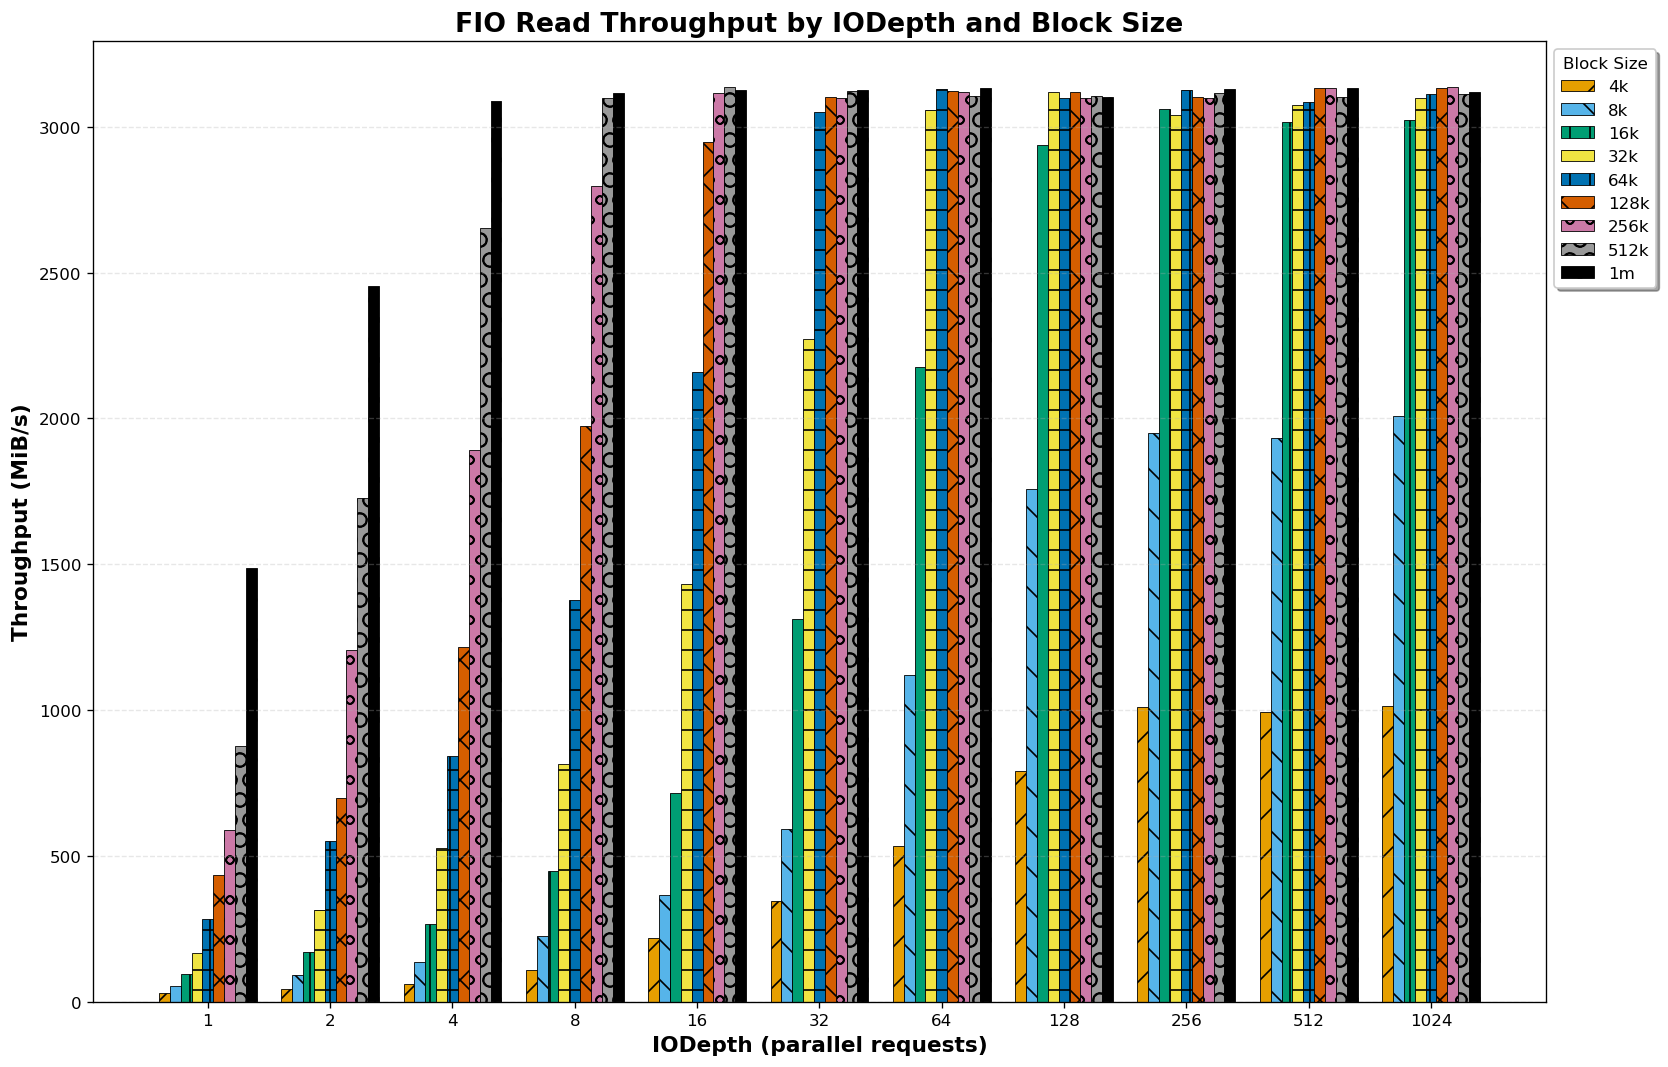

In [20]:
block_order   = ["4k", "8k", "16k", "32k", "64k", "128k", "256k", "512k", "1m"]
iodepth_order = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

fio["block_size"] = pd.Categorical(fio["block_size"], categories=block_order, ordered=True)
fio["iodepth"]    = pd.Categorical(fio["iodepth"],    categories=iodepth_order, ordered=True)
fio_sorted = fio.sort_values(["iodepth", "block_size"])

iodepths   = [i for i in iodepth_order if i in fio["iodepth"].values]
n_bs       = len(block_order)
x          = np.arange(len(iodepths))
width      = 0.8 / n_bs

fig, ax = plt.subplots(figsize=(14, 9))

for i, bs in enumerate(block_order):
    values = [
        fio_sorted[(fio_sorted["iodepth"] == iod) & (fio_sorted["block_size"] == bs)]["bandwidth_mib_s"].values[0]
        if len(fio_sorted[(fio_sorted["iodepth"] == iod) & (fio_sorted["block_size"] == bs)]) > 0
        else 0
        for iod in iodepths
    ]

    ax.bar(x + i * width, values, width,
           label=bs,
           color=colors[i % len(colors)],
           hatch=patterns[i % len(patterns)],
           edgecolor="black", linewidth=0.5)

ax.set_title("FIO Read Throughput by IODepth and Block Size", fontsize=16, fontweight="bold")
ax.set_xlabel("IODepth (parallel requests)", fontsize=13, fontweight="bold")
ax.set_ylabel("Throughput (MiB/s)", fontsize=13, fontweight="bold")
ax.set_xticks(x + width * (n_bs - 1) / 2)
ax.set_xticklabels(iodepths)
ax.legend(title="Block Size", bbox_to_anchor=(1, 1), loc="upper left",
          frameon=True, fancybox=True, shadow=True)
ax.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

The disk's maximum read throughput looks to be slightly above 3GiB/s.
It's attainable with as few as 4 parallel requests and a 1MiB block size, or
1024 parallel requests and a 32KiB block size.

## Sequential Search — Throughput by Block Size

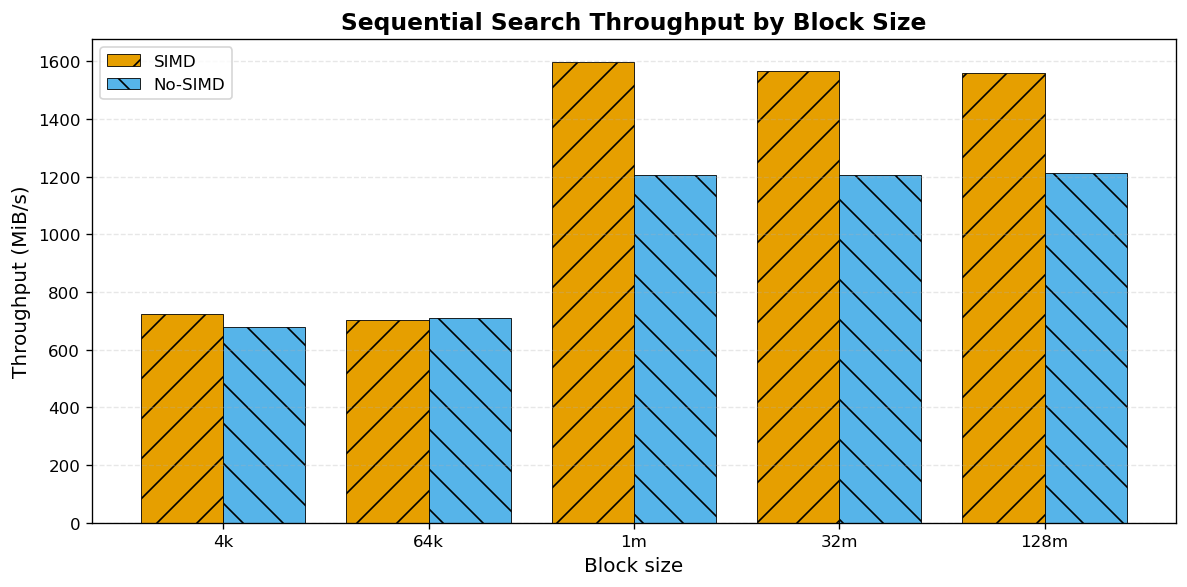

In [21]:
if seq.empty:
    print("No sequential data yet.")
else:
    block_sizes = sorted(seq["block_size_kb"].unique())
    simd_modes  = [(True, "SIMD"), (False, "No-SIMD")]

    x     = np.arange(len(block_sizes))
    width = 0.8 / len(simd_modes)

    fig, ax = plt.subplots(figsize=(10, 5))
    for j, (simd_val, label) in enumerate(simd_modes):
        grp    = seq[seq["simd"] == simd_val].set_index("block_size_kb")["throughput_mib_s"]
        values = grp.reindex(block_sizes).tolist()
        ax.bar(x + j * width, values, width, label=label,
               color=colors[j % len(colors)], hatch=patterns[j % len(patterns)],
               edgecolor="black", linewidth=0.5)

    bs_labels = [f"{int(bs)}k" if bs < 1024 else f"{int(bs // 1024)}m" for bs in block_sizes]
    ax.set_xticks(x + width * (len(simd_modes) - 1) / 2)
    ax.set_xticklabels(bs_labels)
    ax.set_title("Sequential Search Throughput by Block Size", fontsize=14, fontweight="bold")
    ax.set_xlabel("Block size", fontsize=12)
    ax.set_ylabel("Throughput (MiB/s)", fontsize=12)
    ax.legend()
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()


This is surprising: going from 4KiB to 64KiB block size should improve
performance, but it does not here. Looking to at the fio charts, we should
definitely be seeing an improvement however.

For the 1MiB block size, it makes sense that we're able to see a big difference
with SIMD: it's simply more efficient to read through the 1MiB array by
vectorizing.
We get slightly less performance after 1m, which is probably because we spend
too much time loading in memory before getting any work done, and the L3 cache
is only 32MiB.

## Async Search — Throughput by Block Size and Read/Search Parallelism

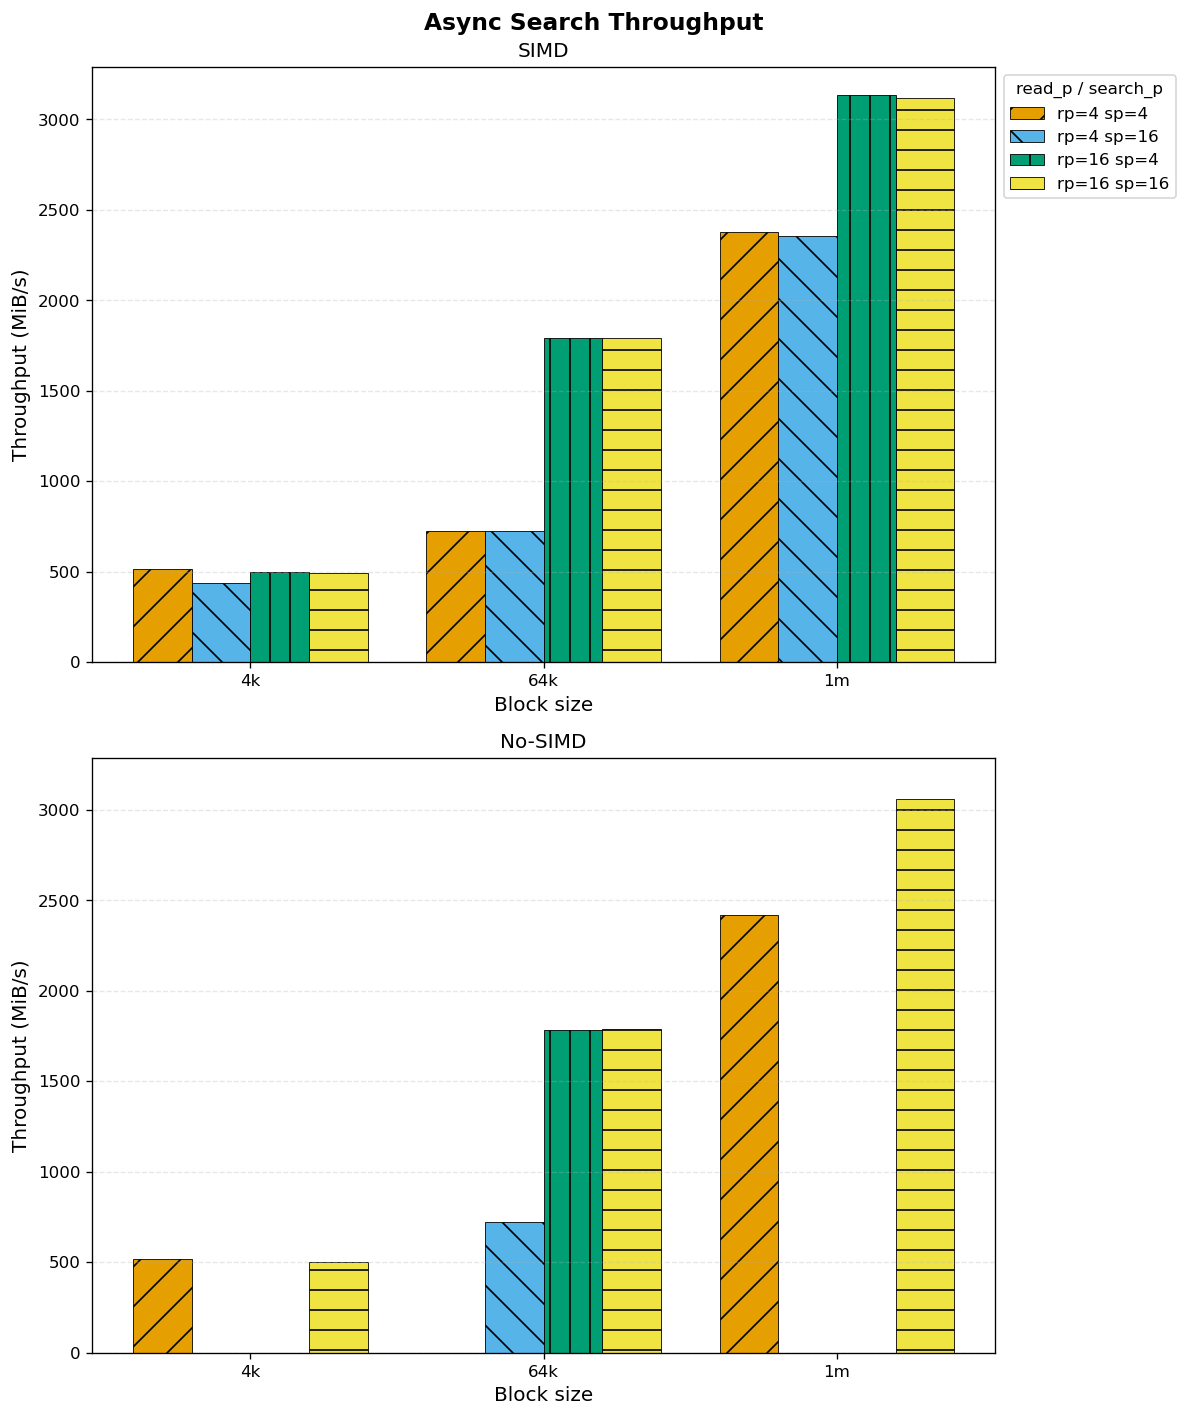

In [22]:
if asyn.empty:
    print("No async data yet.")
else:
    def _async_panel(ax, data, block_sizes, rp_sp_combos, title):
        x     = np.arange(len(block_sizes))
        width = 0.8 / len(rp_sp_combos)
        for j, (rp, sp) in enumerate(rp_sp_combos):
            values = [
                data[(data["block_size_kb"] == bs) & (data["read_parallelism"] == rp) & (data["search_parallelism"] == sp)]["throughput_mib_s"].values[0]
                if len(data[(data["block_size_kb"] == bs) & (data["read_parallelism"] == rp) & (data["search_parallelism"] == sp)]) > 0
                else np.nan
                for bs in block_sizes
            ]
            ax.bar(x + j * width, values, width, label=f"rp={rp} sp={sp}",
                   color=colors[j % len(colors)], hatch=patterns[j % len(patterns)],
                   edgecolor="black", linewidth=0.5)
        bs_labels = [f"{int(bs)}k" if bs < 1024 else f"{int(bs // 1024)}m" for bs in block_sizes]
        ax.set_xticks(x + width * (len(rp_sp_combos) - 1) / 2)
        ax.set_xticklabels(bs_labels)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Block size", fontsize=12)
        ax.grid(axis="y", alpha=0.3, linestyle="--")

    simd_modes   = [(True, "SIMD"), (False, "No-SIMD")]
    block_sizes  = sorted(asyn["block_size_kb"].unique())
    rp_sp_combos = sorted(asyn.groupby(["read_parallelism", "search_parallelism"]).groups.keys())

    fig, axes = plt.subplots(len(simd_modes), 1, figsize=(10, 6 * len(simd_modes)), sharey=True)
    if len(simd_modes) == 1:
        axes = [axes]

    for i, (simd_val, simd_label) in enumerate(simd_modes):
        _async_panel(axes[i], asyn[asyn["simd"] == simd_val], block_sizes, rp_sp_combos, simd_label)
        axes[i].set_ylabel("Throughput (MiB/s)", fontsize=12)

    axes[0].legend(title="read_p / search_p", bbox_to_anchor=(1, 1), loc="upper left")
    fig.suptitle("Async Search Throughput", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


We seem to attain incredible performance with the async approach, with a
sufficiently big block size and enough read workers. Search workers don't seem
to change very much for performance. SIMD also doesn't seem to make much of a difference (though, let's see in the last cell for that.)

Note: this is missing some data for the no-simd version.

## SIMD Speedup — Ratio per Mode and Block Size

For sequential, each (block_size, SIMD) pair is compared directly.
For parallel and async, the ratio is averaged across all parallelism configurations (the SIMD benefit is expected to be largely independent of the parallelism level).

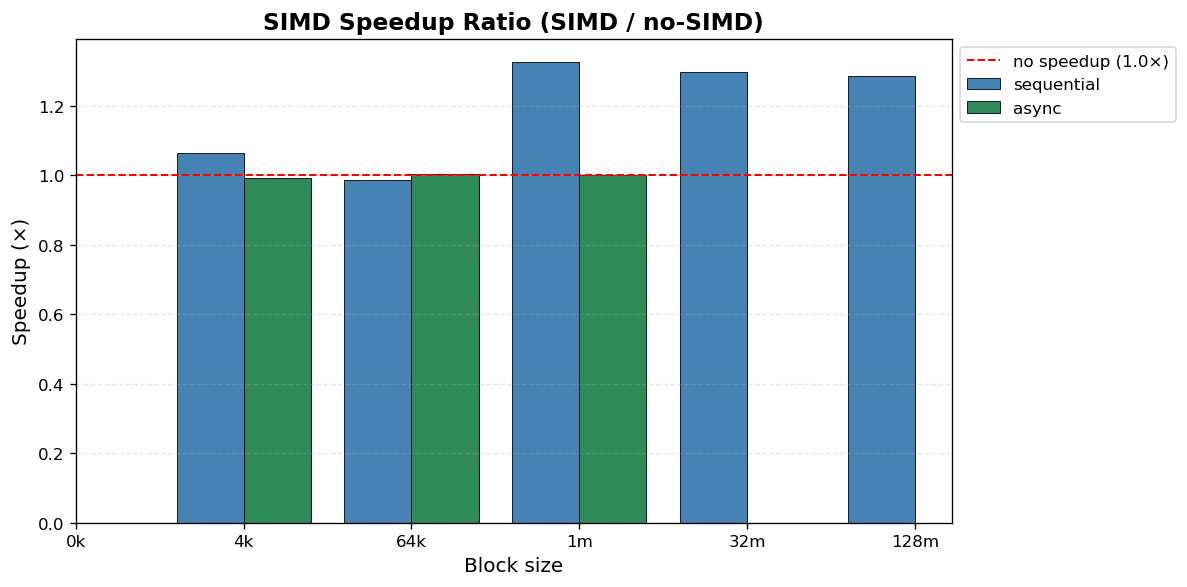

In [23]:
def simd_speedup(df, group_cols):
    """Mean SIMD speedup ratio (SIMD / no-SIMD) per block_size.
    For parallel/async, ratios are averaged across parallelism configurations.
    """
    if df.empty:
        return pd.Series(dtype=float)
    key_cols = ["block_size_kb"] + group_cols
    on  = df[df["simd"] == True ][key_cols + ["throughput_mib_s"]].set_index(key_cols)["throughput_mib_s"]
    off = df[df["simd"] == False][key_cols + ["throughput_mib_s"]].set_index(key_cols)["throughput_mib_s"]
    ratio = (on / off).reset_index()
    return ratio.groupby("block_size_kb")["throughput_mib_s"].mean()

seq_ratio  = simd_speedup(seq,  [])
par_ratio  = simd_speedup(par,  ["parallelism", "batch_multiplier"])
asyn_ratio = simd_speedup(asyn, ["read_parallelism", "search_parallelism"])

all_bs = sorted(set(seq_ratio.index.tolist() + par_ratio.index.tolist() + asyn_ratio.index.tolist()))

if not all_bs:
    print("No benchmark data yet.")
else:
    modes_ratio = [
        ("sequential", seq_ratio,  "steelblue"),
        ("async",      asyn_ratio, "seagreen"),
    ]

    x     = np.arange(len(all_bs))
    width = 0.8 / len(modes_ratio)
    fig, ax = plt.subplots(figsize=(10, 5))

    for j, (label, ratio_series, color) in enumerate(modes_ratio):
        if ratio_series.empty:
            continue
        values = ratio_series.reindex(all_bs).tolist()
        ax.bar(x + j * width, values, width, label=label, color=color,
               edgecolor="black", linewidth=0.5)

    ax.axhline(1.0, color="red", linestyle="--", linewidth=1.2, label="no speedup (1.0×)")
    bs_labels = [f"{int(bs)}k" if bs < 1024 else f"{int(bs // 1024)}m" for bs in all_bs]
    ax.set_xticks(x + width * (len(modes_ratio) - 1) / 2)
    ax.set_xticklabels(bs_labels)
    ax.set_title("SIMD Speedup Ratio (SIMD / no-SIMD)", fontsize=14, fontweight="bold")
    ax.set_xlabel("Block size", fontsize=12)
    ax.set_ylabel("Speedup (×)", fontsize=12)
    ax.legend(bbox_to_anchor=(1, 1), loc="upper left")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()

This is slightly surprising: SIMD doesn't seem to make a difference for the
async-based approach.

## Max performance comparison

In [27]:
rows = [
    ("fio",        fio_sorted["bandwidth_mib_s"].max()   if not fio_sorted.empty else float("nan")),
    ("sequential", seq["throughput_mib_s"].max()         if not seq.empty        else float("nan")),
    ("async",      asyn["throughput_mib_s"].max()        if not asyn.empty       else float("nan")),
]

summary = pd.DataFrame(rows, columns=["mode", "max_throughput_mib_s"])
summary["max_throughput_mib_s"] = summary["max_throughput_mib_s"].round(1)
summary


,mode,max_throughput_mib_s
0,fio,3137.2
1,sequential,1597.5
2,async,3133.2


The async version is thus pretty performant, nearly performing as good as FIO.

Could we have something better? The manufacturer rates the disk at 3470MiB/s maximum.